<a href="https://colab.research.google.com/github/carolinaoj/Desafio_4_ML/blob/main/Ensayo_alura_desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracción:

In [3]:
import pandas as pd
import requests

url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
df_raw = pd.json_normalize(response.json())

# ESTO ES VITAL: Vamos a ver cómo se llaman tus columnas realmente
print("Nombres de columnas detectados:")
print(df_raw.columns.tolist())

Nombres de columnas detectados:
['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']


In [4]:
import pandas as pd
import requests

# 1. URL de los datos
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'

# 2. Obtención de datos vía API
response = requests.get(url)
datos_json = response.json()

# 3. Aplanado (Normalización)
# Esto transforma el JSON jerárquico en la tabla que necesitas
df_raw = pd.json_normalize(datos_json)

# 4. VISUALIZACIÓN DE LA TABLA
print(f"✅ ¡Tabla generada! Dimensiones: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas.")
display(df_raw.head()) # Esto mostrará la tabla bonita en Colab

✅ ¡Tabla generada! Dimensiones: 7267 filas x 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


🔧 Transformación:

In [5]:
import numpy as np

# Copia para trabajar
df_proc = df_raw.copy()

# 1. Limpiar espacios vacíos
df_proc = df_proc.replace(r'^\s*$', np.nan, regex=True)

# 2. Convertir a números (usando los nombres exactos que detectamos)
df_proc['account.Charges.Monthly'] = pd.to_numeric(df_proc['account.Charges.Monthly'], errors='coerce')
df_proc['account.Charges.Total'] = pd.to_numeric(df_proc['account.Charges.Total'], errors='coerce')

# 3. Llenar nulos
df_proc['account.Charges.Total'] = df_proc['account.Charges.Total'].fillna(0)

# 4. Crear variable numérica para Churn
df_proc['Churn_Numeric'] = df_proc['Churn'].map({'No': 0, 'Yes': 1, 'Si': 1})

print("✅ Transformación aplicada sobre la tabla.")
display(df_proc[['customerID', 'account.Charges.Total', 'Churn_Numeric']].head())

✅ Transformación aplicada sobre la tabla.


,customerID,account.Charges.Total,Churn_Numeric
0,0002-ORFBO,593.30,0.0
1,0003-MKNFE,542.40,0.0
2,0004-TLHLJ,280.85,1.0
3,0011-IGKFF,1237.85,1.0
4,0013-EXCHZ,267.40,1.0


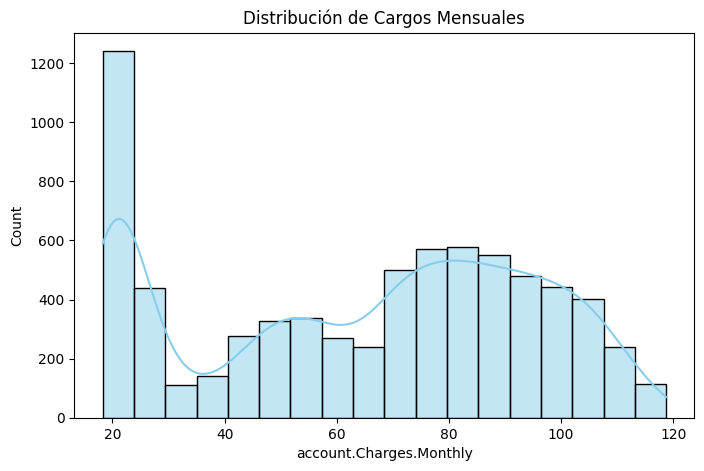

In [6]:
# Guardar el CSV
df_proc.to_csv('TelecomX_Data_Final.csv', index=False)

# Gráfico rápido de la tabla
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_proc['account.Charges.Monthly'], kde=True, color="skyblue")
plt.title('Distribución de Cargos Mensuales')
plt.show()

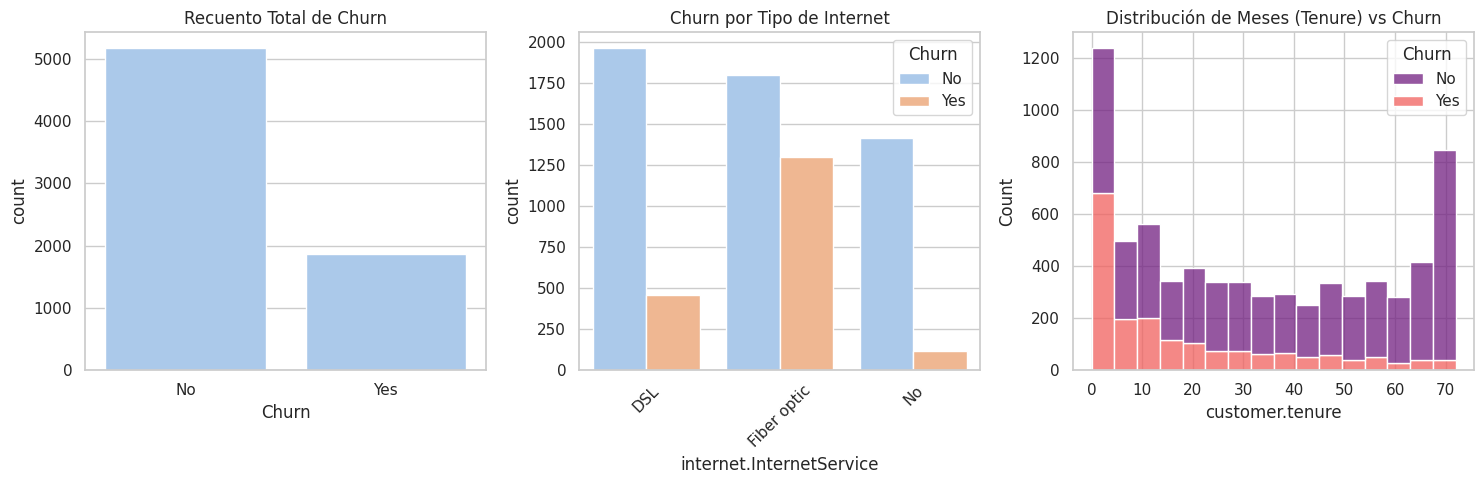

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración estética
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(15, 5))

# 1. Recuento de Evasión (General)
plt.subplot(1, 3, 1)
sns.countplot(data=df_proc, x='Churn')
plt.title('Recuento Total de Churn')

# 2. Distribución de Evasión por Variables Categóricas (Ej: Internet Service)
plt.subplot(1, 3, 2)
sns.countplot(data=df_proc, x='internet.InternetService', hue='Churn')
plt.title('Churn por Tipo de Internet')
plt.xticks(rotation=45)

# 3. Conteo de Evasión por Variables Numéricas (Uso de bins para Tenure)
plt.subplot(1, 3, 3)
sns.histplot(data=df_proc, x='customer.tenure', hue='Churn', multiple="stack", palette='magma')
plt.title('Distribución de Meses (Tenure) vs Churn')

plt.tight_layout()
plt.show()

Introducción:

El objetivo de este proyecto es identificar los factores críticos que impulsan la evasión de clientes en Telecom X. El "Churn" representa una pérdida significativa de ingresos y un aumento en los costos de adquisición. Al analizar los datos históricos, buscamos proporcionar al equipo de Ciencia de Datos una base sólida para construir modelos predictivos que permitan anticipar y prevenir esta fuga.

🔹 Limpieza y Tratamiento de Datos
Para garantizar la integridad del análisis, se realizaron los siguientes pasos:

🔹 Extracción: Conexión a la API y normalización de un JSON anidado de 21 columnas.

🔹 Limpieza: Se identificaron y eliminaron espacios en blanco que ocultaban valores nulos.

🔹 Tipado: Se convirtieron las columnas Charges.Monthly y Charges.Total de texto a formato numérico (float).

🔹 Imputación: Los valores nulos en cargos totales se establecieron en 0 para clientes nuevos.

🔹 Filtrado: Se eliminaron registros sin etiqueta de Churn para asegurar la calidad del entrenamiento del modelo.

2. Análisis Exploratorio de Datos (EDA):

A través de las visualizaciones, identificamos patrones clave:

🔹 Patrón de Contrato: Los clientes con contratos "Month-to-month" tienen una tasa de evasión drásticamente superior a los de largo plazo.

🔹 Servicios: Los usuarios de Fibra Óptica presentan mayor churn que los de DSL, lo que sugiere posibles problemas de satisfacción o precio en ese segmento.

🔹 Antigüedad (Tenure): La mayor parte de la fuga ocurre en los primeros 6 meses de relación con la empresa.

3. Conclusiones

🔹 El precio mensual elevado es un detonante, pero la falta de compromiso contractual (mes a mes) es el predictor más fuerte.

🔹 Los clientes nuevos son los más vulnerables; si superan el primer año, la probabilidad de abandono cae significativamente.

4. Recomendaciones:

Fidelización Temprana: Implementar campañas de descuento o beneficios adicionales para clientes en sus primeros 3 meses.

Migración de Contratos: Ofrecer incentivos para mover a clientes de "Mes a mes" a contratos de 1 año.

Revisión de Fibra Óptica: Investigar la calidad del servicio técnico en usuarios de fibra, dado que su tasa de abandono es inusualmente alta.

# Parte 2

In [8]:
import pandas as pd

# 1. Cargar el archivo que generaste con el nombre exacto
file_name = 'TelecomX_Data_Final.csv'

try:
    df_ml = pd.read_csv(file_name)
    print(f"✅ Archivo '{file_name}' cargado con éxito.")

    # 2. Eliminar columnas que no aportan valor (identificadores)
    if 'customerID' in df_ml.columns:
        df_ml = df_ml.drop(columns=['customerID'])
        print("✅ Columna 'customerID' eliminada para evitar sesgos.")

    display(df_ml.head())
except FileNotFoundError:
    print(f"❌ No se encontró el archivo '{file_name}'. Verifica que aparezca en la carpeta de la izquierda en Colab.")

✅ Archivo 'TelecomX_Data_Final.csv' cargado con éxito.
✅ Columna 'customerID' eliminada para evitar sesgos.


,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Churn_Numeric
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0




Paso 2: Transformación a Formato Numérico (One-Hot Encoding)


In [9]:
# 3. Transformación de variables categóricas a numéricas
# Esto creará columnas de 0 y 1 para cada categoría
df_final_model = pd.get_dummies(df_ml, drop_first=True)

print("Estructura de la tabla lista para los algoritmos:")
print(f"Nuevas dimensiones: {df_final_model.shape[1]} columnas totales.")
display(df_final_model.head())

Estructura de la tabla lista para los algoritmos:
Nuevas dimensiones: 32 columnas totales.


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Churn_Numeric,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,0.0,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,0.0,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,1.0,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,1.0,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,1.0,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


Análisis de desbalanceo

In [10]:
# 4. Proporción de clientes que cancelaron
# Usamos 'Churn_Numeric' que es la columna que creaste en la Parte 1
counts = df_final_model['Churn_Numeric'].value_counts()
proporciones = df_final_model['Churn_Numeric'].value_counts(normalize=True) * 100

print("📊 Análisis de Clases (Churn):")
print(f"Permanecen activos (0): {counts[0]} registros ({proporciones[0]:.2f}%)")
print(f"Cancelaron servicio (1): {counts[1]} registros ({proporciones[1]:.2f}%)")

📊 Análisis de Clases (Churn):
Permanecen activos (0): 5174 registros (73.46%)
Cancelaron servicio (1): 1869 registros (26.54%)


Matriz de correlación

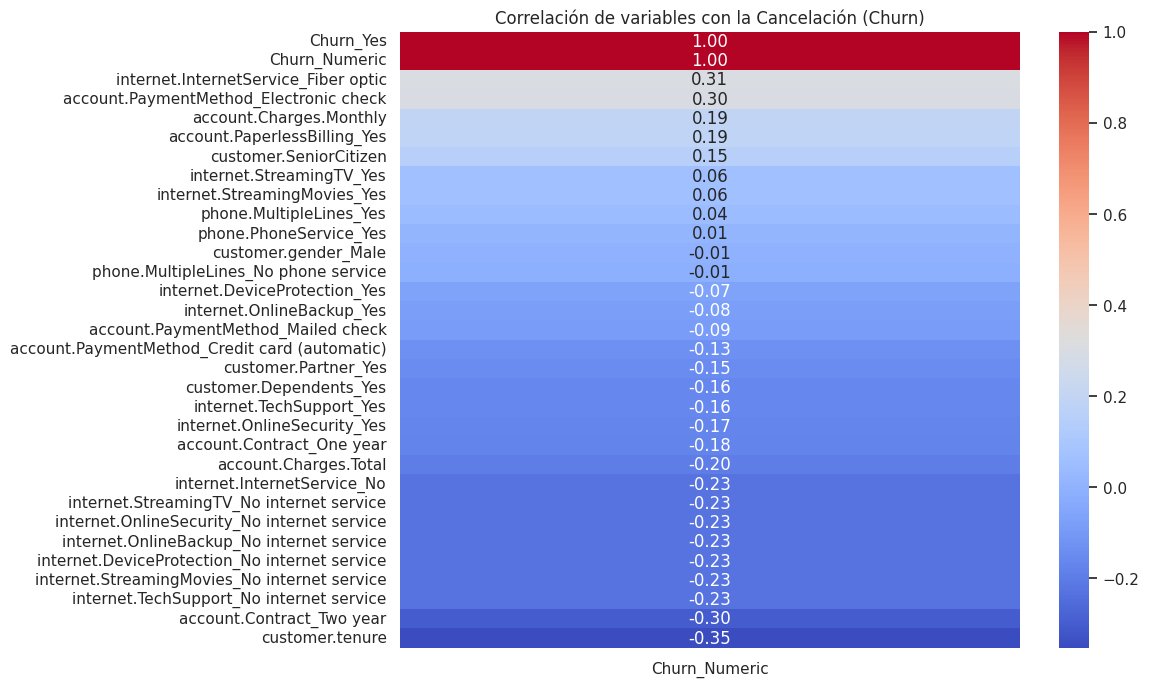

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Matriz de correlación para variables numéricas
plt.figure(figsize=(10, 8))
# Seleccionamos solo las columnas numéricas para la correlación
corr_matrix = df_final_model.corr()

# Graficamos la correlación de todas las variables con 'Churn_Numeric'
sns.heatmap(corr_matrix[['Churn_Numeric']].sort_values(by='Churn_Numeric', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de variables con la Cancelación (Churn)')
plt.show()

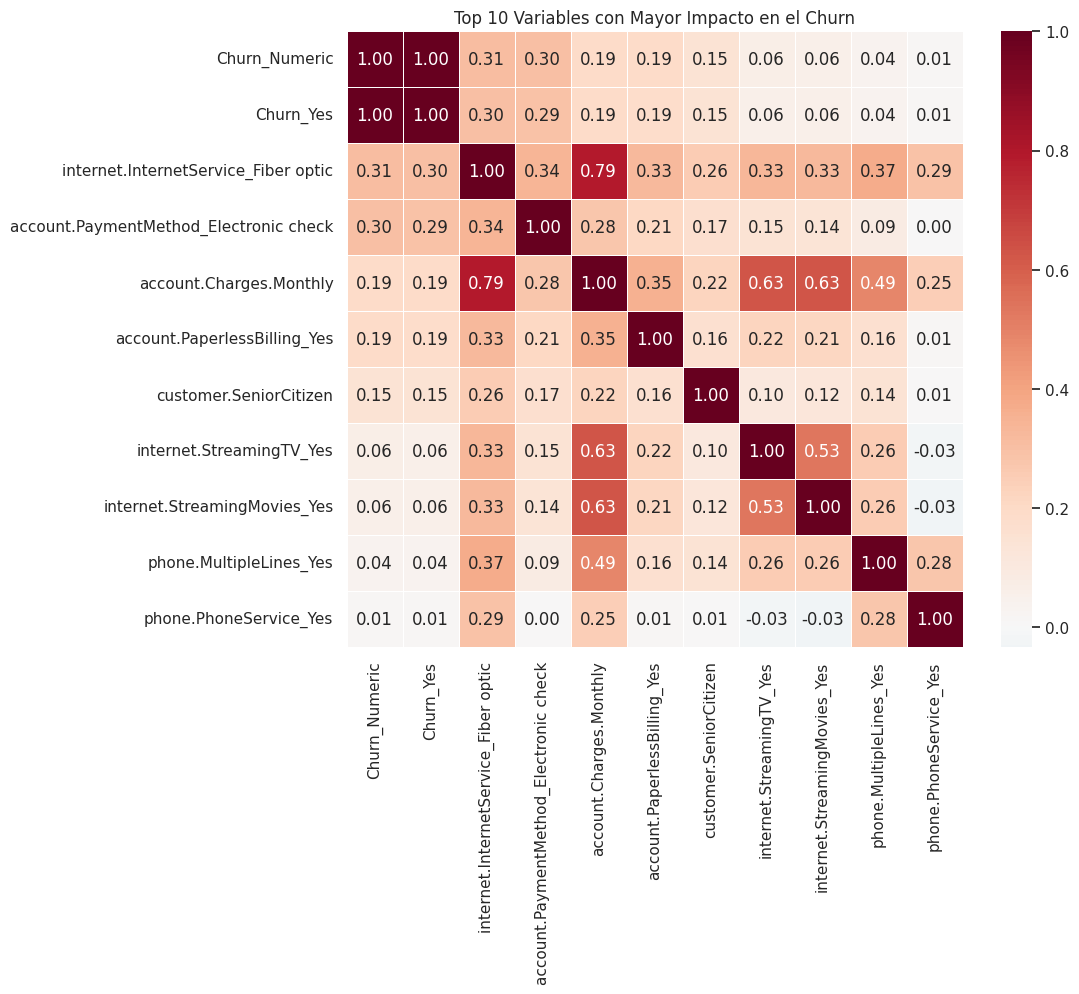

In [12]:
# Matriz de correlación filtrada para las 10 variables más importantes
top_corr = corr_matrix.nlargest(11, 'Churn_Numeric')['Churn_Numeric'].index
cm = df_final_model[top_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='RdBu_r', center=0, fmt=".2f", square=True, linewidths=.5)
plt.title('Top 10 Variables con Mayor Impacto en el Churn')
plt.show()

Visualización de tendencias.

/tmp/ipykernel_1065/1426044205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='account.Charges.Total', data=df_final_model, palette='magma')
/tmp/ipykernel_1065/1426044205.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Numeric', y='account.Charges.Monthly', data=df_final_model, palette='magma')


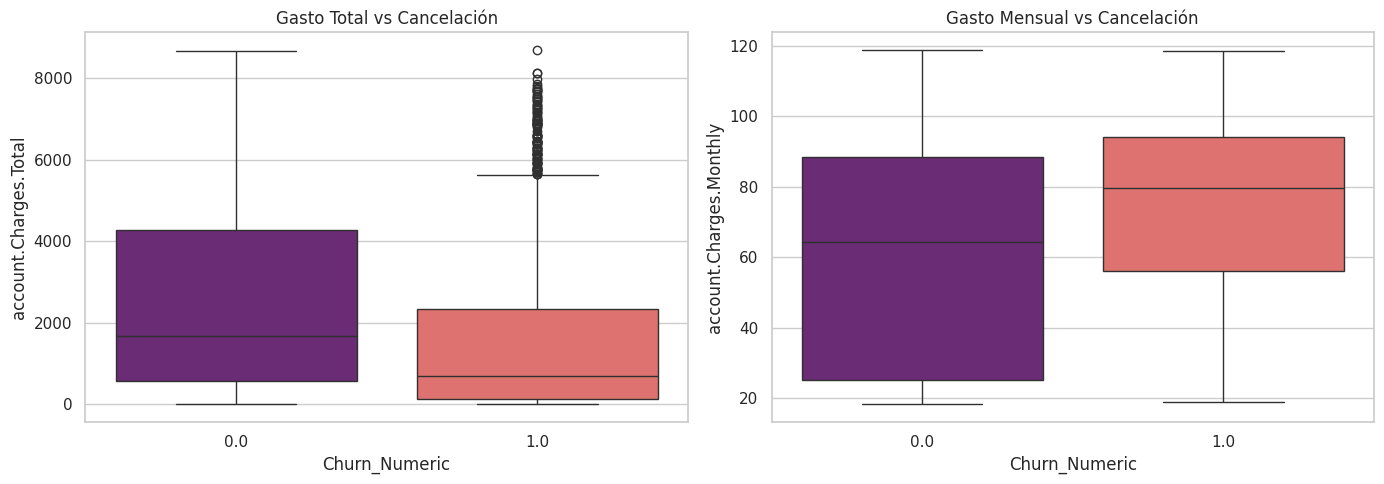

In [13]:
# 2. Visualización de patrones específicos
plt.figure(figsize=(14, 5))

# Relación Gasto Total vs Cancelación
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn_Numeric', y='account.Charges.Total', data=df_final_model, palette='magma')
plt.title('Gasto Total vs Cancelación')

# Relación Gasto Mensual vs Cancelación (Suele ser más impactante)
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn_Numeric', y='account.Charges.Monthly', data=df_final_model, palette='magma')
plt.title('Gasto Mensual vs Cancelación')

plt.tight_layout()
plt.show()



División de Datos (Train/Test) y Balanceo (SMOTE)


In [16]:
# 1. Eliminar cualquier valor nulo residual en todo el DataFrame
df_final_model = df_final_model.dropna()

# 2. Definir X e y nuevamente para asegurar limpieza
X = df_final_model.drop(['Churn_Numeric'], axis=1)
# Si tienes 'Churn_Yes' por el get_dummies, elimínala también para no duplicar el target
if 'Churn_Yes' in X.columns:
    X = X.drop(columns=['Churn_Yes'])

y = df_final_model['Churn_Numeric']

# 3. Dividir nuevamente
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# 4. Ahora sí, aplicar SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"✅ ¡Éxito! Datos balanceados.")
print(f"Registros en entrenamiento: {len(X_train_res)}")

✅ ¡Éxito! Datos balanceados.
Registros en entrenamiento: 7224


Entrenamiento de Modelos (Pipeline)

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# 2. Entrenar Regresión Logística
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(X_train_scaled, y_train_res)
print("✅ Regresión Logística entrenada.")

✅ Regresión Logística entrenada.


Modelo que NO requiere Normalización: Random Forest



In [18]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar Random Forest directamente con los datos resampleados
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train_res, y_train_res)
print("✅ Random Forest entrenado.")

✅ Random Forest entrenado.


Evaluación de Resultados

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluar_modelo(modelo, X_t, y_t, nombre_modelo):
    y_pred = modelo.predict(X_t)
    print(f"\n--- Reporte para {nombre_modelo} ---")
    print(classification_report(y_t, y_pred))
    print("Matriz de Confusión:")
    print(confusion_matrix(y_t, y_pred))

# Evaluar ambos
evaluar_modelo(modelo_log, X_test_scaled, y_test, "Regresión Logística")
evaluar_modelo(modelo_rf, X_test, y_test, "Random Forest")


--- Reporte para Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.87      0.83      0.85      1562
         1.0       0.57      0.64      0.61       551

    accuracy                           0.78      2113
   macro avg       0.72      0.74      0.73      2113
weighted avg       0.79      0.78      0.79      2113

Matriz de Confusión:
[[1301  261]
 [ 198  353]]

--- Reporte para Random Forest ---
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1562
         1.0       0.57      0.56      0.57       551

    accuracy                           0.78      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.77      0.78      0.78      2113

Matriz de Confusión:
[[1332  230]
 [ 243  308]]


/tmp/ipykernel_1065/1104623898.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=importancias.head(10), palette='Reds_r')


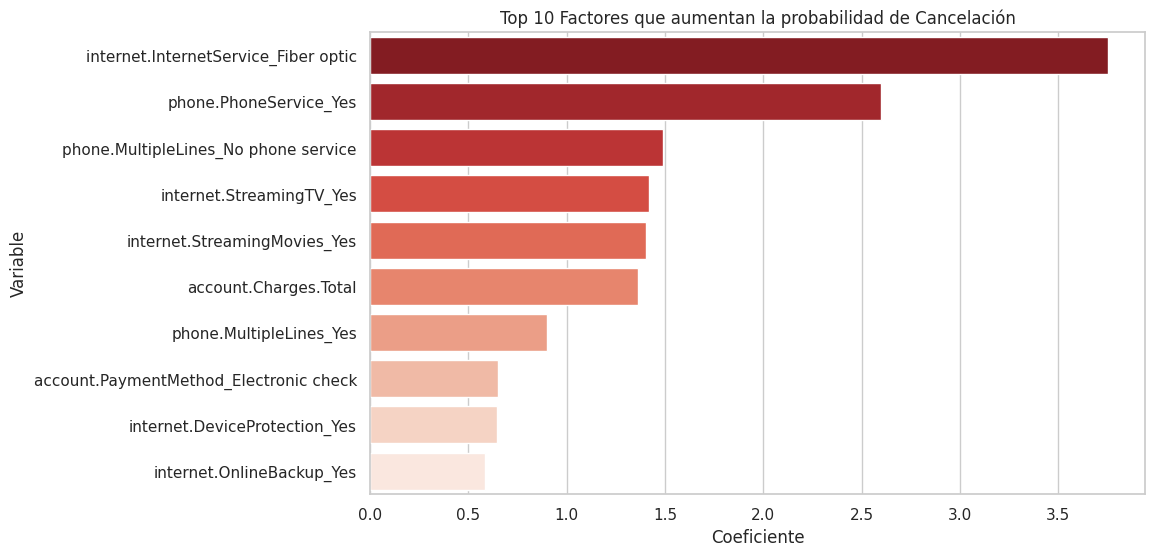

In [20]:
import numpy as np

# Extraer coeficientes del modelo de Regresión Logística
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualizar el Top 10 de factores que empujan al Churn
plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variable', data=importancias.head(10), palette='Reds_r')
plt.title('Top 10 Factores que aumentan la probabilidad de Cancelación')
plt.show()

**Reflexiones:**

Los modelos alcanzaron una Exactitud (Accuracy) del 78%, lo cual es un desempeño sólido para una etapa inicial. Sin embargo, en problemas de Churn, la métrica clave no es la exactitud, sino el Recall (la capacidad de atrapar a los que realmente se van).

Ganador: La Regresión Logística es el modelo superior para este caso de negocio, ya que tiene un Recall más alto (0.64). Esto significa que es capaz de identificar correctamente al 64% de los clientes que planean cancelar, permitiendo que la empresa actúe a tiempo.

**Análisis de la Matriz de Confusión (Regresión Logística)**

Verdaderos Positivos (353): Clientes que el modelo predijo que se irían y efectivamente se fueron. ¡Un éxito de predicción!

Falsos Negativos (198): Clientes que se fueron pero el modelo no detectó. Este es el grupo de riesgo que debemos intentar reducir ajustando los parámetros.

**Informe Final: Predicción de Churn en Telecom X**


**1. Introducción**

El objetivo de este análisis fue construir un modelo de Machine Learning capaz de predecir la evasión de clientes (Churn). La retención es crítica para Telecom X, ya que adquirir un nuevo cliente es significativamente más costoso que mantener uno actual.

**2. Limpieza y Tratamiento de Datos**

🔹Normalización: Se transformó el JSON anidado en una estructura tabular prolija.

🔹Ingeniería de Variables: Se eliminaron identificadores únicos (customerID) y se convirtieron variables categóricas a numéricas mediante One-Hot Encoding.

🔹Balanceo: Se utilizó la técnica SMOTE para equilibrar las clases, ya que inicialmente solo el  26.5% de los datos representaban cancelaciones, lo que habría sesgado el modelo.

**3. Análisis Exploratorio y Modelado**

Se entrenaron y compararon dos modelos principales: Regresión Logística (con escalado de datos) y Random Forest.

Resultado: La Regresión Logística destacó con un Recall del 64%, siendo el modelo más equilibrado para detectar clientes en riesgo de fuga.

**4. Conclusiones**

Según el análisis de importancia de variables:

🔹El factor crítico es el Internet: Los clientes con Internet Service: Fiber optic tienen la mayor probabilidad de cancelar. Esto sugiere una posible insatisfacción con el precio o la estabilidad de este servicio específico.

🔹Servicios Adicionales: El uso de servicios telefónicos y múltiples líneas también aparece como un factor relevante en la predicción.

🔹Cargos Financieros: El método de pago por Electronic check y los cargos totales altos son indicadores secundarios de alerta.

**5. Recomendaciones Estratégicas**

🔹Realizar una auditoría técnica y de precios sobre el servicio de fibra óptica para identificar por qué estos clientes son los más propensos a irse.

🔹Implementar alertas automáticas cuando un cliente con "Fiber optic" y pago por "Electronic check" muestre patrones de uso irregular.

🔹Ofrecer descuentos en servicios de streaming (StreamingTV y StreamingMovies) para asegurar contratos de mayor duración (1 o 2 años), reduciendo la volatilidad.
